In [ ]:
%pip install torch==1.12.0
%pip install torchvision==0.13.0

In [ ]:
%pip install pandas==1.2.4 -i https://pypi.tuna.tsinghua.edu.cn/simple

In [5]:
import d2l
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"d2l版本: {d2l.__version__}")
print(f"pandas版本: {pd.__version__}")
print("安装成功！")

d2l版本: 1.0.3
pandas版本: 2.0.3
安装成功！


# 数据操作

[**张量表示一个由数值组成的数组，这个数组可能有多个维度**]。
具有一个轴的张量对应数学上的*向量*（vector）；
具有两个轴的张量对应数学上的*矩阵*（matrix）；
具有两个轴以上的张量没有特殊的数学名称。

In [ ]:
import torch
x=torch.arange(12)  #张量表述一个数值生成的数组
x

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [ ]:
x.shape  #访问张量的形状
x.numel() #张量元素的总数
X=x.reshape(3,4) #改变张量的形状
X

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

In [12]:
torch.tensor([[2,1,4,3],[1,2,3,4],[4,3,2,1]])
torch.tensor([[2,1,4,3],[1,2,3,4],[4,3,2,1]]).shape

torch.Size([3, 4])

算术运算符

In [14]:
x=torch.tensor([1.0,2,4,8])
y=torch.tensor([2,2,2,2])
x+y,x-y,x*y,x/y,x**y
torch.exp(x)

tensor([2.7183e+00, 7.3891e+00, 5.4598e+01, 2.9810e+03])

[**我们也可以把多个张量*连结*（concatenate）在一起**]，
把它们端对端地叠起来形成一个更大的张量。
我们只需要提供张量列表，并给出沿哪个轴连结。

In [15]:
X = torch.arange(12, dtype=torch.float32).reshape((3,4))
Y = torch.tensor([[2.0, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])
torch.cat((X, Y), dim=0), torch.cat((X, Y), dim=1)

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
         [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
         [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]))

In [16]:
X.sum()

tensor(66.)

广播机制
在上面的部分中，我们看到了如何在相同形状的两个张量上执行按元素操作。
在某些情况下，[**即使形状不同，我们仍然可以通过调用
*广播机制*（broadcasting mechanism）来执行按元素操作**]。
这种机制的工作方式如下：

1. 通过适当复制元素来扩展一个或两个数组，以便在转换之后，两个张量具有相同的形状；
2. 对生成的数组执行按元素操作。

In [17]:
a = torch.arange(3).reshape((3, 1))
b = torch.arange(2).reshape((1, 2))
a, b

(tensor([[0],
         [1],
         [2]]),
 tensor([[0, 1]]))

In [18]:
a + b


tensor([[0, 1],
        [1, 2],
        [2, 3]])

索引切片

In [19]:
X[-1], X[1:3]

(tensor([ 8.,  9., 10., 11.]),
 tensor([[ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]]))

In [20]:
X[1, 2] = 9
X

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  9.,  7.],
        [ 8.,  9., 10., 11.]])

节省内存

[**运行一些操作可能会导致为新结果分配内存**]。

In [21]:
before = id(Y)
Y = Y + X
id(Y) == before

False

将深度学习框架定义的张量[**转换为NumPy张量（`ndarray`）**]很容易，反之也同样容易。
torch张量和numpy数组将共享它们的底层内存，就地操作更改一个张量也会同时更改另一个张量

In [22]:
A = X.numpy()
B = torch.tensor(A)
type(A), type(B)

(numpy.ndarray, torch.Tensor)

In [23]:
a = torch.tensor([3.5])
a, a.item(), float(a), int(a)

(tensor([3.5000]), 3.5, 3.5, 3)

In [24]:
X == Y

tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])

In [25]:
X < Y

tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])

In [26]:
X>Y

tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])

# 数据预处理

读取数据

In [27]:
import os

os.makedirs(os.path.join('..', 'data'), exist_ok=True)
data_file = os.path.join('..', 'data', 'house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('NumRooms,Alley,Price\n')  # 列名
    f.write('NA,Pave,127500\n')  # 每行表示一个数据样本
    f.write('2,NA,106000\n')
    f.write('4,NA,178100\n')
    f.write('NA,NA,140000\n')

In [ ]:

import pandas as pd

data = pd.read_csv(data_file)
print(data)

   NumRooms Alley   Price
0       NaN  Pave  127500
1       2.0   NaN  106000
2       4.0   NaN  178100
3       NaN   NaN  140000


处理缺失值
[**为了处理缺失的数据，典型的方法包括*插值法*和*删除法*，**]


In [ ]:
import pandas as pd

# 读取数据
data = pd.read_csv(data_file)

# 取输入输出
inputs, outputs = data.iloc[:, 0:2], data.iloc[:, 2]

inputs = inputs.apply(pd.to_numeric, errors='coerce')
inputs = inputs.fillna(inputs.mean(numeric_only=True))

print(inputs)

   NumRooms  Alley
0       3.0    NaN
1       2.0    NaN
2       4.0    NaN
3       3.0    NaN


转换为张量

In [35]:
import torch

X, y = torch.tensor(inputs.values), torch.tensor(outputs.values)
X, y

(tensor([[3., nan],
         [2., nan],
         [4., nan],
         [3., nan]], dtype=torch.float64),
 tensor([127500, 106000, 178100, 140000]))

In [36]:
import pandas as pd
import torch
import numpy as np

# ===================== 1. 创建包含更多行和列的原始数据集 =====================
# 生成10行5列的数据集，包含随机缺失值（NaN）
np.random.seed(42)  # 固定随机种子，保证结果可复现
data = pd.DataFrame(
    np.random.randn(10, 5),  # 10行5列的随机数
    columns=['特征A', '特征B', '特征C', '特征D', '特征E']
)
# 随机插入缺失值，模拟真实数据
data = data.mask(np.random.random(data.shape) < 0.2)  # 20%的概率变为NaN
print("=== 原始数据集 ===")
print(data)
print("\n各列缺失值数量：")
print(data.isnull().sum())

# ===================== 2. 删除缺失值最多的列 =====================
# 计算每列的缺失值数量
nan_count = data.isnull().sum()
# 找到缺失值最多的列名
col_to_drop = nan_count.idxmax()
print(f"\n=== 缺失值最多的列：{col_to_drop}（共{nan_count[col_to_drop]}个缺失值）===")
# 删除该列
data_processed = data.drop(columns=[col_to_drop])
print("\n=== 删除缺失值最多的列后的数据集 ===")
print(data_processed)

# ===================== 3. 将预处理后的数据集转换为张量格式 =====================
# 对剩余列进行缺失值填充（用均值填充，避免转换报错）
data_filled = data_processed.fillna(data_processed.mean(numeric_only=True))
# 转换为PyTorch张量
tensor_data = torch.tensor(data_filled.values, dtype=torch.float32)
print("\n=== 最终转换后的张量 ===")
print(tensor_data)
print(f"张量形状：{tensor_data.shape}")

=== 原始数据集 ===
        特征A       特征B       特征C       特征D       特征E
0       NaN -0.138264       NaN  1.523030 -0.234153
1       NaN       NaN  0.767435 -0.469474  0.542560
2 -0.463418       NaN  0.241962       NaN -1.724918
3 -0.562288 -1.012831       NaN -0.908024 -1.412304
4  1.465649 -0.225776  0.067528 -1.424748       NaN
5  0.110923 -1.150994  0.375698 -0.600639 -0.291694
6 -0.601707  1.852278       NaN       NaN       NaN
7 -1.220844  0.208864 -1.959670 -1.328186  0.196861
8  0.738467  0.171368 -0.115648       NaN -1.478522
9       NaN -0.460639  1.057122  0.343618 -1.763040

各列缺失值数量：
特征A    3
特征B    2
特征C    3
特征D    3
特征E    2
dtype: int64

=== 缺失值最多的列：特征A（共3个缺失值）===

=== 删除缺失值最多的列后的数据集 ===
        特征B       特征C       特征D       特征E
0 -0.138264       NaN  1.523030 -0.234153
1       NaN  0.767435 -0.469474  0.542560
2       NaN  0.241962       NaN -1.724918
3 -1.012831       NaN -0.908024 -1.412304
4 -0.225776  0.067528 -1.424748       NaN
5 -1.150994  0.375698 -0.600639 -0.291694


# 线性代数

标量由只有一个元素的张量表示

In [37]:
import torch

x = torch.tensor(3.0)
y = torch.tensor(2.0)

x + y, x * y, x / y, x**y

(tensor(5.), tensor(6.), tensor(1.5000), tensor(9.))

向量被视为标量值组成的列表

In [38]:
x = torch.arange(4)
x

tensor([0, 1, 2, 3])

In [39]:
x[3]

tensor(3)

长度，维度和形状

In [41]:
len(x)
x.shape


torch.Size([4])

当调用函数来实例化张量时，
我们可以[**通过指定两个分量$m$和$n$来创建一个形状为$m \times n$的矩阵**]。

In [43]:
A = torch.arange(20).reshape(5, 4)
A

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])

转置

In [44]:
A.T


tensor([[ 0,  4,  8, 12, 16],
        [ 1,  5,  9, 13, 17],
        [ 2,  6, 10, 14, 18],
        [ 3,  7, 11, 15, 19]])

In [45]:
X = torch.arange(24).reshape(2, 3, 4)
X

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

张量算法的基本性质

标量、向量、矩阵和任意数量轴的张量（本小节中的“张量”指代数对象）有一些实用的属性。
例如，从按元素操作的定义中可以注意到，任何按元素的一元运算都不会改变其操作数的形状。
同样，[**给定具有相同形状的任意两个张量，任何按元素二元运算的结果都将是相同形状的张量**]。
例如，将两个相同形状的矩阵相加，会在这两个矩阵上执行元素加法。

In [46]:
A = torch.arange(20, dtype=torch.float32).reshape(5, 4)
B = A.clone()  # 通过分配新内存，将A的一个副本分配给B
A, A + B

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([[ 0.,  2.,  4.,  6.],
         [ 8., 10., 12., 14.],
         [16., 18., 20., 22.],
         [24., 26., 28., 30.],
         [32., 34., 36., 38.]]))

In [47]:
A * B


tensor([[  0.,   1.,   4.,   9.],
        [ 16.,  25.,  36.,  49.],
        [ 64.,  81., 100., 121.],
        [144., 169., 196., 225.],
        [256., 289., 324., 361.]])

In [48]:
a = 2
X = torch.arange(24).reshape(2, 3, 4)
a + X, (a * X).shape

(tensor([[[ 2,  3,  4,  5],
          [ 6,  7,  8,  9],
          [10, 11, 12, 13]],
 
         [[14, 15, 16, 17],
          [18, 19, 20, 21],
          [22, 23, 24, 25]]]),
 torch.Size([2, 3, 4]))

降维

In [49]:
x = torch.arange(4, dtype=torch.float32)
x, x.sum()

(tensor([0., 1., 2., 3.]), tensor(6.))

In [50]:
A.shape, A.sum()

(torch.Size([5, 4]), tensor(190.))

In [51]:
A_sum_axis0 = A.sum(axis=0)
A_sum_axis0, A_sum_axis0.shape

(tensor([40., 45., 50., 55.]), torch.Size([4]))

In [52]:
A.mean(), A.sum() / A.numel()

(tensor(9.5000), tensor(9.5000))

点积

In [53]:
y = torch.ones(4, dtype = torch.float32)
x, y, torch.dot(x, y)

(tensor([0., 1., 2., 3.]), tensor([1., 1., 1., 1.]), tensor(6.))

矩阵向量积

In [54]:
A.shape, x.shape, torch.mv(A, x)

(torch.Size([5, 4]), torch.Size([4]), tensor([ 14.,  38.,  62.,  86., 110.]))

矩阵乘法

In [ ]:
B = torch.ones(4, 3)
torch.mm(A, B)


线性代数中最有用的一些运算符是*范数*（norm）。
非正式地说，向量的*范数*是表示一个向量有多大。
这里考虑的*大小*（size）概念不涉及维度，而是分量的大小。

在线性代数中，向量范数是将向量映射到标量的函数$f$。
给定任意向量$\mathbf{x}$，向量范数要满足一些属性。

In [55]:
u = torch.tensor([3.0, -4.0])
torch.norm(u)

tensor(5.)

In [56]:
torch.abs(u).sum()

tensor(7.)

In [57]:
torch.norm(torch.ones((4, 9)))


tensor(6.)

# 微积分

导数和微分

In [58]:
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l


def f(x):
    return 3 * x ** 2 - 4 * x

In [59]:
def numerical_lim(f, x, h):
    return (f(x + h) - f(x)) / h

h = 0.1
for i in range(5):
    print(f'h={h:.5f}, numerical limit={numerical_lim(f, 1, h):.5f}')
    h *= 0.1

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


In [60]:
def use_svg_display():  #@save
    """使用svg格式在Jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

In [61]:
def set_figsize(figsize=(3.5, 2.5)):  #@save
    """设置matplotlib的图表大小"""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

In [62]:
#@save
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

In [63]:
#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """绘制数据点"""
    if legend is None:
        legend = []

    set_figsize(figsize)
    axes = axes if axes else d2l.plt.gca()

    # 如果X有一个轴，输出True
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

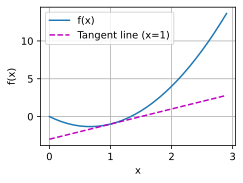

In [64]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

# 自动微分

In [66]:
import torch

x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [68]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [67]:
x.requires_grad_(True)  # 等价于x=torch.arange(4.0,requires_grad=True)
x.grad  # 默认值是None

In [69]:
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [70]:
x.grad == 4 * x

tensor([True, True, True, True])

In [71]:
# 在默认情况下，PyTorch会累积梯度，我们需要清除之前的值
x.grad.zero_()
y = x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

反向传播

In [ ]:

x.grad.zero_()
y = x * x
# 等价于y.backward(torch.ones(len(x)))
y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

分离计算

In [73]:
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x

z.sum().backward()
x.grad == u

tensor([True, True, True, True])

In [74]:
x.grad.zero_()
y.sum().backward()
x.grad == 2 * x

tensor([True, True, True, True])

python控制流的梯度计算
使用自动微分的一个好处是：
[**即使构建函数的计算图需要通过Python控制流（例如，条件、循环或任意函数调用），我们仍然可以计算得到的变量的梯度**]。


In [76]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

In [77]:
a.grad == d / a

tensor(True)